# High Chl

In [1]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting as oc_plotting

from bing.models import anw as bing_anw
from bing.models import bbnw as bing_bbnw
from bing import inference as bing_inf
from bing import rt as bing_rt
from bing import chisq_fit

import anly_utils

In [3]:
#%matplotlib ipympl

# Load

## L23

In [4]:
ds = loisel23.load_ds(4,0)

### Unpack

In [8]:
l23_wave = ds.Lambda.data
l23_Rrs = ds.Rrs.data
a = ds.a.data
bb = ds.bb.data
adg = ds.ag.data + ds.ad.data
ag = ds.ag.data
ad = ds.ad.data
aph = ds.aph.data
anw = ds.anw.data

# Find high aph

In [7]:
srt = np.argsort(aph[:,6])
srt[-10:]

array([2773, 1997,  221, 2553, 2626, 2398, 2298, 2956, 2949, 2950])

## Chl

In [15]:
i440 = np.argmin(np.abs(l23_wave-440.))
Chla = aph[:,i440] / 0.05582
Chla.min(), Chla.max()

(np.float32(0.015263347), np.float32(8.445539))

In [16]:
Chla[170]

np.float32(0.13061626)

# Examine one

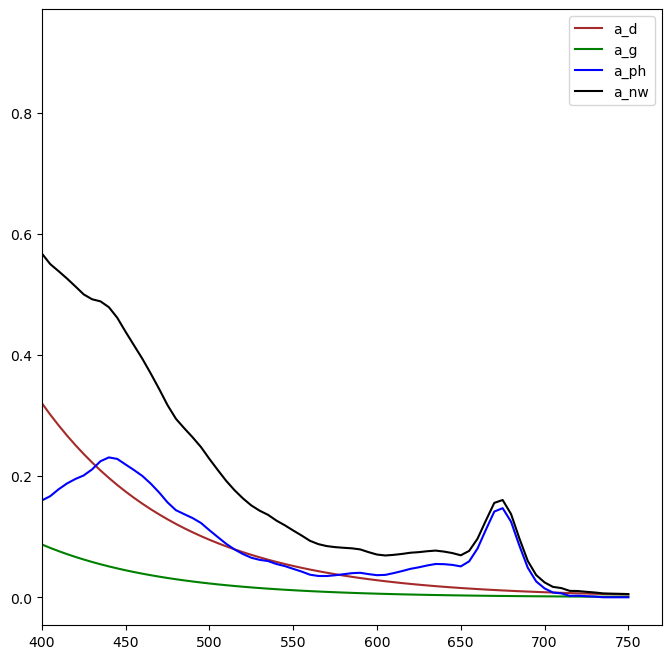

In [12]:
idx = 2773
#
fig = plt.figure(figsize=(8,8))
ax = plt.gca()
#
ax.plot(l23_wave, ad[idx], color='brown', label='a_d')
ax.plot(l23_wave, ag[idx], color='green', label='a_g')
ax.plot(l23_wave, aph[idx], color='b', label='a_ph')
ax.plot(l23_wave, anw[idx], color='k', label='a_nw')
#
ax.legend()
ax.set_xlim(400., None)
#
plt.show()